<a href="https://colab.research.google.com/github/Basmala135/grad_project/blob/main/Grad-version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls -lah "/content/drive/MyDrive"


total 143M
-rw------- 1 root root  1.1M Mar  5  2025  21010359_perihanetarek.pdf
-rw------- 1 root root  1.8M Apr 14  2025  21010428_21010366_21010359_21010994_AnalogIc_Lab1.pdf
-rw------- 1 root root  8.0K Dec 14  2024  30206100202621.jpg
-rw------- 1 root root   21K Dec 14  2024  30206100202621.pdf
-rw------- 1 root root  1.8M May  8  2025 'ANALOG IC 3.pdf'
-rw------- 1 root root  2.0M Dec 20 20:34  antenna_lab2.pdf
-rw------- 1 root root  2.7M Dec 19 20:08  Antenna_reports.pdf
-rw------- 1 root root  6.6M Aug  5  2025  Assign2_21010359.pdf
-rw------- 1 root root   16M Aug 15  2025  Assign4.pdf
-rw------- 1 root root  6.9M Aug 23  2025  Assign5_21010359.pdf
-rw------- 1 root root  8.2M Aug 25  2025  Assign6_21010359.pdf
-rw------- 1 root root   18M Aug 27  2025  Assign7-21010359.pdf
-rw------- 1 root root   17M Sep  1  2025  Assign8-21010359.pdf
-rw------- 1 root root   15M Sep  3  2025  Assign9-21010359.pdf
-rw------- 1 root root  938K Aug  1  2025  assignment_1.zip
-rw------- 1 roo

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/normal data/normal.csv"

df = pd.read_csv(file_path)


In [ ]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== COLUMNS ===")
print(df.columns.tolist())

print("\n=== FIRST 3 ROWS ===")
print(df.head(3))

print("\n=== BASIC STATS ===")
print(df.describe())

print("\n=== NULL VALUES ===")
print(df.isnull().sum())

print("\n=== DTYPES ===")
print(df.dtypes)


=== SHAPE ===
(5102330, 6)

=== COLUMNS ===
['ax', 'ay', 'az', 'gx', 'gy', 'gz']

=== FIRST 3 ROWS ===
         ax        ay        az        gx        gy        gz
0  0.370398  0.484220  1.029756  1.250994 -0.138326 -0.061255
1 -0.123669  0.310492  1.380223 -0.666899  0.650407 -0.390476
2  0.429197  0.012149  0.692698 -1.847173 -0.902243 -0.128224

=== BASIC STATS ===
                 ax            ay            az            gx            gy  \
count  5.102330e+06  5.102330e+06  5.102330e+06  5.102330e+06  5.102330e+06   
mean   1.104486e-02  1.185922e-02  9.995861e-01 -1.509297e-03 -2.109742e-02   
std    2.518309e-01  1.189277e-01  1.675455e-01  2.928097e-01  2.164624e-01   
min   -7.646074e+00 -1.952706e+00 -3.316994e+00 -1.042908e+01 -9.959892e+00   
25%   -1.276028e-01 -5.869170e-02  9.089145e-01 -1.223450e-01 -1.100200e-01   
50%    2.685933e-04  2.054733e-02  9.995406e-01 -1.359000e-03 -1.223300e-02   
75%    1.380378e-01  9.166464e-02  1.094040e+00  1.188900e-01  6.836300e-02

In [ ]:
import os
import pandas as pd

folder_path = "/content/drive/MyDrive/fall data"

csv_files = [
    os.path.join(folder_path, file)
    for file in os.listdir(folder_path)
    if file.endswith(".csv")
]

print("Number of CSV files:", len(csv_files))

for file_path in csv_files:
    print("\n" + "="*80)
    print("FILE:", os.path.basename(file_path))
    print("="*80)

    try:
        df = pd.read_csv(
            file_path,
            encoding='latin1',
            sep='\t',               # ← force tab separator
            header=0,               # first row is the header
            usecols=[1, 2, 3, 4, 5, 6],  # skip time column, take 6 sensor cols
            names=['_h', 'ax', 'ay', 'az', 'gx', 'gy', 'gz'],  # rename
            skiprows=1              # skip original header since we're renaming
        )
        # Drop the dummy header col if it snuck in
        df = df[['ax', 'ay', 'az', 'gx', 'gy', 'gz']]
        df = df.apply(pd.to_numeric, errors='coerce').dropna()

    except Exception as e:
        print("ERROR:", e)
        continue

    print("=== SHAPE ===")
    print(df.shape)

    print("\n=== FIRST 3 ROWS ===")
    print(df.head(3))

    print("\n=== BASIC STATS ===")
    print(df.describe())

    print("\n=== DTYPES ===")
    print(df.dtypes)

Number of CSV files: 11

FILE: Harsh breaking On Straight Line.csv
ERROR: Number of passed names did not match number of header fields in the file

FILE: Much degraded track.csv
ERROR: Number of passed names did not match number of header fields in the file

FILE: Fall Like manoeuvre 1.csv
ERROR: Number of passed names did not match number of header fields in the file

FILE: Acceleration On Straight Line.csv
ERROR: Number of passed names did not match number of header fields in the file

FILE: Fall Like manoeuvre 2.csv
ERROR: Number of passed names did not match number of header fields in the file

FILE: Acceleration On Curve.csv
ERROR: Number of passed names did not match number of header fields in the file

FILE: Fall Like manoeuvre 3.csv
ERROR: Number of passed names did not match number of header fields in the file

FILE: Fall with leaning of the motorcycle.csv
ERROR: Number of passed names did not match number of header fields in the file

FILE: Fall in the roundabout.csv
ERROR: N

In [ ]:
import pandas as pd

# Just peek at ONE file raw
file_path = "/content/drive/MyDrive/fall data/Fall in a curve.csv"

# Read raw lines to see exactly what's in there
with open(file_path, encoding='latin1') as f:
    for i, line in enumerate(f):
        print(repr(line))  # repr() shows \t and \n characters explicitly
        if i == 4:         # just first 5 lines
            break

'time(s)\tAx(m/s²)\tAy(m/s²)\tAz(m/s²)\tRx(°/s)\tRy.(°/s)\tRz(°/s)\t\t\t\t\t\t\t\t\t\t\n'
'0.001\t0.000\t0.000\t0.000\t0.000\t0.000\t0.000\t\n'
'0.002\t0.000\t0.000\t0.000\t0.000\t0.000\t0.000\t\n'
'0.003\t0.000\t0.000\t0.000\t0.000\t0.000\t0.000\t\n'
'0.004\t0.000\t0.000\t0.000\t0.000\t0.000\t0.000\t\n'


In [ ]:
import os
import pandas as pd

folder_path = "/content/drive/MyDrive/fall data"

csv_files = [
    os.path.join(folder_path, file)
    for file in os.listdir(folder_path)
    if file.endswith(".csv")
]

print("Number of CSV files:", len(csv_files))

for file_path in csv_files:
    print("\n" + "="*80)
    print("FILE:", os.path.basename(file_path))
    print("="*80)

    try:
        df = pd.read_csv(
            file_path,
            encoding='latin1',
            sep='\t',
            header=0,
            usecols=[0, 1, 2, 3, 4, 5, 6],   # take exactly the 7 real columns
            engine='python'                    # more flexible with messy files
        )

        # Rename to standard names
        df.columns = ['time', 'ax', 'ay', 'az', 'gx', 'gy', 'gz']

        # Drop time, convert to numeric, drop bad rows
        df = df[['ax', 'ay', 'az', 'gx', 'gy', 'gz']]
        df = df.apply(pd.to_numeric, errors='coerce').dropna()

        print("=== SHAPE ===")
        print(df.shape)

        print("\n=== FIRST 3 ROWS ===")
        print(df.head(3))

        print("\n=== BASIC STATS ===")
        print(df.describe())

        print("\n=== DTYPES ===")
        print(df.dtypes)

    except Exception as e:
        print("ERROR:", e)

Number of CSV files: 11

FILE: Harsh breaking On Straight Line.csv
=== SHAPE ===
(111485, 6)

=== FIRST 3 ROWS ===
    ax   ay   az   gx   gy   gz
0  0.0  0.0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0  0.0  0.0

=== BASIC STATS ===
                  ax             ay             az             gx  \
count  111485.000000  111485.000000  111485.000000  111485.000000   
mean       -0.031125       0.067427       9.742392      -0.376806   
std         1.541427       0.056100       0.402716       5.110271   
min       -10.161000      -0.145000       0.000000     -45.568000   
25%        -0.097000       0.022000       9.626000      -0.280000   
50%        -0.048000       0.046000       9.680000      -0.110000   
75%        -0.010000       0.094000       9.770000       0.000000   
max         9.219000       0.382000      13.783000      95.536000   

                  gy             gz  
count  111485.000000  111485.000000  
mean        0.385915       1.900249  


In [ ]:
import pandas as pd

df_normal = pd.read_csv("/content/drive/MyDrive/normal data/normal.csv")  # adjust path

print("NORMAL DATA - All channel ranges:")
print(df_normal[['ax','ay','az','gx','gy','gz']].describe().loc[['min','mean','max','std']])

NORMAL DATA - All channel ranges:
            ax        ay        az         gx        gy        gz
min  -7.646074 -1.952706 -3.316994 -10.429083 -9.959892 -9.946112
mean  0.011045  0.011859  0.999586  -0.001509 -0.021097 -0.004627
max   4.519341  7.920774  5.764458  10.239907  9.189062  9.900241
std   0.251831  0.118928  0.167545   0.292810  0.216462  0.144531


In [ ]:
import pandas as pd

# Load normal data
df_normal = pd.read_csv("/content/drive/MyDrive/normal data/normal.csv")  # adjust path

print("BEFORE conversion:")
print(df_normal[['ax','ay','az','gx','gy','gz']].describe().loc[['min','mean','max','std']])

# ── Fix accelerometer: g → m/s² ──────────────────────────────────
df_normal[['ax', 'ay', 'az']] = df_normal[['ax', 'ay', 'az']] * 9.81

# ── Fix gyroscope: ×10 to match fall data scale ──────────────────
df_normal[['gx', 'gy', 'gz']] = df_normal[['gx', 'gy', 'gz']] * 10

print("\nAFTER conversion:")
print(df_normal[['ax','ay','az','gx','gy','gz']].describe().loc[['min','mean','max','std']])
print("\nQuick sanity checks:")
print(f"  az mean (should be ~9.81): {df_normal['az'].mean():.3f}")
print(f"  gx max  (should be ~100):  {df_normal['gx'].max():.3f}")

# ── Save ──────────────────────────────────────────────────────────
output_path = "/content/drive/MyDrive/normal_riding_converted.csv"
df_normal.to_csv(output_path, index=False)
print(f"\nSaved → {output_path}")

BEFORE conversion:
            ax        ay        az         gx        gy        gz
min  -7.646074 -1.952706 -3.316994 -10.429083 -9.959892 -9.946112
mean  0.011045  0.011859  0.999586  -0.001509 -0.021097 -0.004627
max   4.519341  7.920774  5.764458  10.239907  9.189062  9.900241
std   0.251831  0.118928  0.167545   0.292810  0.216462  0.144531

AFTER conversion:
             ax         ay         az          gx         gy         gz
min  -75.007982 -19.156050 -32.539715 -104.290830 -99.598920 -99.461120
mean   0.108350   0.116339   9.805940   -0.015093  -0.210974  -0.046274
max   44.334739  77.702797  56.549329  102.399070  91.890620  99.002410
std    2.470462   1.166681   1.643621    2.928097   2.164624   1.445308

Quick sanity checks:
  az mean (should be ~9.81): 9.806
  gx max  (should be ~100):  102.399

Saved → /content/drive/MyDrive/normal_riding_converted.csv


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, auc
)
import tensorflow as tf
from tensorflow import keras

# ── Paths ────────────────────────────────────────────────────────────────────
# normal_riding_converted.csv = the unit-fixed file we saved earlier
NORMAL_CSV    = "/content/drive/MyDrive/normal_riding_converted.csv"
FALL_FOLDER   = "/content/drive/MyDrive/fall data"
PROCESSED_DIR = Path("data/processed")
MODELS_DIR    = Path("models")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

# ── Sensor channels ──────────────────────────────────────────────────────────
CHANNELS = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

# ── Sliding window config ────────────────────────────────────────────────────
SAMPLE_RATE = 100          # Hz — adjust if your IMU uses a different rate
WINDOW_SEC  = 2.0          # seconds per window
OVERLAP     = 0.5          # 50% overlap between consecutive windows
WINDOW_SIZE = int(SAMPLE_RATE * WINDOW_SEC)      # = 200 samples
STEP_SIZE   = int(WINDOW_SIZE * (1 - OVERLAP))   # = 100 samples

# ── Files to move from fall folder → normal class ────────────────────────────
# These are aggressive-but-normal riding events, NOT accidents.
# Teaching the model "hard braking ≠ accident" makes it more robust.
MOVE_TO_NORMAL = {
    "Harsh breaking On Straight Line.csv",
    "Acceleration On Straight Line.csv",
    "Acceleration On Curve.csv",
    "Much degraded track.csv",
}

# ── Training hyperparameters ─────────────────────────────────────────────────
EPOCHS     = 80
BATCH_SIZE = 32
LR         = 1e-3
FALL_TEST_SIZE   = 0.30
FALL_VAL_SIZE    = 0.20
NORMAL_TEST_SIZE = 0.15
NORMAL_VAL_SIZE  = 0.15

print("Config loaded ✅")
print(f"  Window size : {WINDOW_SIZE} samples ({WINDOW_SEC}s at {SAMPLE_RATE}Hz)")
print(f"  Step size   : {STEP_SIZE} samples ({OVERLAP*100:.0f}% overlap)")


Config loaded ✅
  Window size : 200 samples (2.0s at 100Hz)
  Step size   : 100 samples (50% overlap)


In [ ]:
def strip_zero_rows(df):
    """Remove rows where ALL 6 sensor channels are zero (startup noise)."""
    mask = (df[CHANNELS] != 0).any(axis=1)
    n_removed = (~mask).sum()
    return df[mask].reset_index(drop=True), n_removed


def load_fall_file(file_path):
    """
    Load one tab-separated fall-folder CSV.
    Handles the messy trailing tabs in the header row.
    """
    df = pd.read_csv(
        file_path,
        encoding='latin1',
        sep='\t',
        header=0,
        usecols=[0, 1, 2, 3, 4, 5, 6],   # take only the 7 real columns
        engine='python'
    )
    df.columns = ['time', 'ax', 'ay', 'az', 'gx', 'gy', 'gz']
    df = df[CHANNELS]
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    return df


def load_all_data():
    """
    Returns:
        normal_dfs : list of DataFrames — label 0 (normal riding)
        fall_dfs   : list of DataFrames — label 1 (accident/fall)

    Each element is one recording session (one file).
    Keeping sessions separate is essential for the correct train/test split.
    """
    normal_dfs = []
    fall_dfs   = []

    # ── Normal riding (single large CSV) ─────────────────────────
    print("Loading normal riding data...")
    df_normal = pd.read_csv(NORMAL_CSV)
    df_normal, z = strip_zero_rows(df_normal)
    normal_dfs.append(df_normal)
    print(f"  ✅ Normal riding : {len(df_normal):,} rows  (removed {z:,} zero rows)")

    # ── Fall folder (11 files) ────────────────────────────────────
    print("\nLoading fall folder files...")
    fall_folder = Path(FALL_FOLDER)

    for f in sorted(fall_folder.glob("*.csv")):
        df = load_fall_file(str(f))
        df, z = strip_zero_rows(df)

        if f.name in MOVE_TO_NORMAL:
            normal_dfs.append(df)
            print(f"  [→ NORMAL] {f.name}: {len(df):,} rows  (removed {z:,} zero rows)")
        else:
            fall_dfs.append(df)
            print(f"  [FALL]     {f.name}: {len(df):,} rows  (removed {z:,} zero rows)")

    total_normal = sum(len(d) for d in normal_dfs)
    total_fall   = sum(len(d) for d in fall_dfs)

    print(f"\n{'─'*50}")
    print(f"Total normal rows : {total_normal:,}")
    print(f"Total fall rows   : {total_fall:,}")
    print(f"Imbalance ratio   : {total_normal/total_fall:.1f}× more normal than fall")
    print(f"Normal sessions   : {len(normal_dfs)}")
    print(f"Fall sessions     : {len(fall_dfs)}")

    return normal_dfs, fall_dfs


normal_dfs, fall_dfs = load_all_data()


Loading normal riding data...
  ✅ Normal riding : 5,102,330 rows  (removed 0 zero rows)

Loading fall folder files...
  [→ NORMAL] Acceleration On Curve.csv: 47,911 rows  (removed 24 zero rows)
  [→ NORMAL] Acceleration On Straight Line.csv: 138,279 rows  (removed 24 zero rows)
  [FALL]     Fall Like manoeuvre 1.csv: 132,454 rows  (removed 24 zero rows)
  [FALL]     Fall Like manoeuvre 2.csv: 148,902 rows  (removed 24 zero rows)
  [FALL]     Fall Like manoeuvre 3.csv: 128,422 rows  (removed 24 zero rows)
  [FALL]     Fall in a curve.csv: 78,437 rows  (removed 24 zero rows)
  [FALL]     Fall in the roundabout.csv: 66,341 rows  (removed 24 zero rows)
  [FALL]     Fall on a slippery straight road section.csv: 74,021 rows  (removed 24 zero rows)
  [FALL]     Fall with leaning of the motorcycle.csv: 81,639 rows  (removed 24 zero rows)
  [→ NORMAL] Harsh breaking On Straight Line.csv: 111,461 rows  (removed 24 zero rows)
  [→ NORMAL] Much degraded track.csv: 132,070 rows  (removed 24 zero ro

In [ ]:
def sliding_windows(data, label):
    """
    Slice a (N, 6) array into overlapping windows.
    Returns X shape (n_windows, WINDOW_SIZE, 6) and y shape (n_windows,).
    """
    X, y = [], []
    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        X.append(data[start : start + WINDOW_SIZE])
        y.append(label)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int8)


def sessions_to_windows(session_dfs, label):
    """
    Convert list of session DataFrames → list of (X, y) tuples.
    Each tuple = one session. Sessions stay separate for the split step.
    """
    sessions = []
    for df in session_dfs:
        X, y = sliding_windows(df[CHANNELS].values, label)
        if len(X) > 0:
            sessions.append((X, y))
    return sessions


normal_sessions = sessions_to_windows(normal_dfs, label=0)
fall_sessions   = sessions_to_windows(fall_dfs,   label=1)

total_normal_windows = sum(len(s[0]) for s in normal_sessions)
total_fall_windows   = sum(len(s[0]) for s in fall_sessions)

print(f"Normal sessions with windows : {len(normal_sessions)}")
print(f"Fall sessions with windows   : {len(fall_sessions)}")
print(f"Total normal windows         : {total_normal_windows:,}")
print(f"Total fall windows           : {total_fall_windows:,}")


Normal sessions with windows : 5
Fall sessions with windows   : 7
Total normal windows         : 55,313
Total fall windows           : 7,093


In [ ]:
# ── CELL 5: K-Fold Cross Validation ──────────────────────────────────────────

def concat_sessions(sessions, indices):
    """Concatenate windows from a list of session indices into one array."""
    Xs = [sessions[i][0] for i in indices]
    ys = [sessions[i][1] for i in indices]
    return np.concatenate(Xs), np.concatenate(ys)


# ── Fixed test set ────────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

fall_indices   = list(range(len(fall_sessions)))
normal_indices = list(range(len(normal_sessions)))
np.random.shuffle(fall_indices)
np.random.shuffle(normal_indices)

n_fall_test   = 2
n_normal_test = max(1, int(len(normal_indices) * 0.15))

test_fall_idx       = fall_indices[:n_fall_test]
trainval_fall_idx   = fall_indices[n_fall_test:]
test_normal_idx     = normal_indices[:n_normal_test]
trainval_normal_idx = normal_indices[n_normal_test:]

X_test_f, y_test_f = concat_sessions(fall_sessions,   test_fall_idx)
X_test_n, y_test_n = concat_sessions(normal_sessions, test_normal_idx)

# Fix: undersample fall in test to match realistic ratio (~5% falls)
target_fall_test = int(len(X_test_n) * 0.05)
if len(X_test_f) > target_fall_test:
    idx = np.random.choice(len(X_test_f), target_fall_test, replace=False)
    X_test_f = X_test_f[idx]
    y_test_f = y_test_f[idx]

X_test = np.concatenate([X_test_f, X_test_n])
y_test = np.concatenate([y_test_f, y_test_n])

print(f"Test set — normal: {(y_test==0).sum():,}  fall: {(y_test==1).sum():,}")
print(f"Test fall ratio  : {(y_test==1).sum()/len(y_test):.2%}  (realistic ~5%)")
print(f"Remaining fall sessions for K-Fold: {len(trainval_fall_idx)}")

# ── K-Fold on remaining fall sessions ────────────────────────────────────────
K = 5
kf = KFold(n_splits=min(K, len(trainval_fall_idx)), shuffle=True, random_state=RANDOM_STATE)

fold_results = []
X_normal_trainval, y_normal_trainval = concat_sessions(normal_sessions, trainval_normal_idx)

print(f"\nRunning {min(K, len(trainval_fall_idx))}-Fold Cross Validation...")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(kf.split(trainval_fall_idx)):
    print(f"\n── Fold {fold+1} ──────────────────────────────────────────")

    fold_train_fall_idx = [trainval_fall_idx[i] for i in train_idx]
    fold_val_fall_idx   = [trainval_fall_idx[i] for i in val_idx]

    X_train_f, y_train_f = concat_sessions(fall_sessions, fold_train_fall_idx)
    X_val_f,   y_val_f   = concat_sessions(fall_sessions, fold_val_fall_idx)

    n_val_normal = int(len(X_normal_trainval) * (len(val_idx) / len(trainval_fall_idx)))
    perm = np.random.permutation(len(X_normal_trainval))
    X_val_n   = X_normal_trainval[perm[:n_val_normal]]
    y_val_n   = y_normal_trainval[perm[:n_val_normal]]
    X_train_n = X_normal_trainval[perm[n_val_normal:]]
    y_train_n = y_normal_trainval[perm[n_val_normal:]]

    X_train = np.concatenate([X_train_n, X_train_f])
    y_train = np.concatenate([y_train_n, y_train_f])
    X_val   = np.concatenate([X_val_n,   X_val_f])
    y_val   = np.concatenate([y_val_n,   y_val_f])

    print(f"Train — normal: {(y_train==0).sum():,}  fall: {(y_train==1).sum():,}")
    print(f"Val   — normal: {(y_val==0).sum():,}  fall: {(y_val==1).sum():,}")
    print(f"Val fall ratio: {(y_val==1).sum()/len(y_val):.2%}")

    fold_results.append({
        'fold': fold + 1,
        'X_train': X_train, 'y_train': y_train,
        'X_val':   X_val,   'y_val':   y_val,
    })

print("\n✅ Folds prepared. Now run Cell 6 → 7 → 8 → 9.")

Test set — normal: 1,113  fall: 55
Test fall ratio  : 4.71%  (realistic ~5%)
Remaining fall sessions for K-Fold: 5

Running 5-Fold Cross Validation...

── Fold 1 ──────────────────────────────────────────
Train — normal: 43,360  fall: 2,999
Val   — normal: 10,840  fall: 1,283
Val fall ratio: 10.58%

── Fold 2 ──────────────────────────────────────────
Train — normal: 43,360  fall: 3,467
Val   — normal: 10,840  fall: 815
Val fall ratio: 6.99%

── Fold 3 ──────────────────────────────────────────
Train — normal: 43,360  fall: 3,620
Val   — normal: 10,840  fall: 662
Val fall ratio: 5.76%

── Fold 4 ──────────────────────────────────────────
Train — normal: 43,360  fall: 3,543
Val   — normal: 10,840  fall: 739
Val fall ratio: 6.38%

── Fold 5 ──────────────────────────────────────────
Train — normal: 43,360  fall: 3,499
Val   — normal: 10,840  fall: 783
Val fall ratio: 6.74%

✅ Folds prepared. Now run Cell 6 → 7 → 8 → 9.


In [ ]:
# After Cell 5, add this to see exactly how sessions were distributed
print("Fall session sizes:")
for i, (X, y) in enumerate(fall_sessions):
    print(f"  Session {i}: {len(X):,} windows")

print(f"\nFall windows in train : {(y_train_f==1).sum():,}")
print(f"Fall windows in val   : {(y_val_f==1).sum():,}")
print(f"Fall windows in test  : {(y_test_f==1).sum():,}")

Fall session sizes:
  Session 0: 1,323 windows
  Session 1: 1,488 windows
  Session 2: 1,283 windows
  Session 3: 783 windows
  Session 4: 662 windows
  Session 5: 739 windows
  Session 6: 815 windows

Fall windows in train : 3,499
Fall windows in val   : 783
Fall windows in test  : 55


In [ ]:
# ── CELL 6: Normalize per fold ────────────────────────────────────────────────

def fit_normalize(X_train):
    """Compute per-channel mean and std from training windows only."""
    mean = X_train.mean(axis=(0, 1))
    std  = X_train.std(axis=(0, 1))
    std  = np.where(std < 1e-8, 1e-8, std)
    return mean, std

def apply_normalize(X, mean, std):
    return (X - mean[np.newaxis, np.newaxis, :]) / std[np.newaxis, np.newaxis, :]


for fold_data in fold_results:
    X_tr = fold_data['X_train']
    X_v  = fold_data['X_val']

    mean, std = fit_normalize(X_tr)
    fold_data['X_train'] = apply_normalize(X_tr, mean, std)
    fold_data['X_val']   = apply_normalize(X_v,  mean, std)
    fold_data['mean']    = mean
    fold_data['std']     = std

all_means = np.stack([f['mean'] for f in fold_results])
all_stds  = np.stack([f['std']  for f in fold_results])
test_mean = all_means.mean(axis=0)
test_std  = all_stds.mean(axis=0)

X_test_norm = apply_normalize(X_test, test_mean, test_std)

np.save(PROCESSED_DIR / "norm_mean.npy", test_mean)
np.save(PROCESSED_DIR / "norm_std.npy",  test_std)

print("Normalization done per fold ✅")
print(f"\nESP32 normalization values:")
print(f"float NORM_MEAN[6] = {{{', '.join(f'{v:.6f}f' for v in test_mean)}}};")
print(f"float NORM_STD[6]  = {{{', '.join(f'{v:.6f}f' for v in test_std)}}};")

Normalization done per fold ✅

ESP32 normalization values:
float NORM_MEAN[6] = {0.127849f, 0.111934f, 9.283952f, -0.036534f, -0.442563f, 0.098388f};
float NORM_STD[6]  = {2.446702f, 1.082008f, 2.003945f, 4.665434f, 4.646413f, 4.095118f};


In [ ]:
# ── CELL 7: Oversample per fold ───────────────────────────────────────────────
from sklearn.utils import resample

def oversample_minority(X_train, y_train):
    """Oversample fall windows (label=1) to match normal window count."""
    X_normal = X_train[y_train == 0]
    X_fall   = X_train[y_train == 1]
    y_normal = y_train[y_train == 0]
    y_fall   = y_train[y_train == 1]

    print(f"  Before — normal: {len(X_normal):,}  fall: {len(X_fall):,}")

    X_fall_over, y_fall_over = resample(
        X_fall, y_fall,
        replace=True,
        n_samples=len(X_normal),
        random_state=42
    )

    X_balanced = np.concatenate([X_normal, X_fall_over])
    y_balanced = np.concatenate([y_normal, y_fall_over])

    perm = np.random.permutation(len(X_balanced))
    return X_balanced[perm], y_balanced[perm]


for fold_data in fold_results:
    print(f"Fold {fold_data['fold']}:")
    X_bal, y_bal = oversample_minority(fold_data['X_train'], fold_data['y_train'])
    fold_data['X_train'] = X_bal
    fold_data['y_train'] = y_bal

print("\nOversampling done per fold ✅")

Fold 1:
  Before — normal: 43,360  fall: 2,999
Fold 2:
  Before — normal: 43,360  fall: 3,467
Fold 3:
  Before — normal: 43,360  fall: 3,620
Fold 4:
  Before — normal: 43,360  fall: 3,543
Fold 5:
  Before — normal: 43,360  fall: 3,499

Oversampling done per fold ✅


In [ ]:
# ── CELL 8: Focal Loss + Model Architecture ───────────────────────────────────

def focal_loss(gamma=2.0, alpha=0.75):
    """
    Focal loss — focuses training on hard examples.
    alpha=0.75 means fall class gets 3x more weight than normal class.
    gamma=2.0 down-weights easy examples so model focuses on hard ones.
    """
    def loss(y_true, y_pred):
        y_true  = tf.cast(y_true, tf.float32)
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce     = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha  + (1 - y_true) * (1 - alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * bce)
    return loss


def build_model():
    inp = keras.Input(shape=(WINDOW_SIZE, 6), name="imu_input")

    # Block 1: short impulse patterns (~70ms at 100Hz)
    x = keras.layers.Conv1D(32, kernel_size=7, padding='same', activation='relu')(inp)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling1D(pool_size=2)(x)
    x = keras.layers.Dropout(0.2)(x)

    # Block 2: medium patterns (~50ms)
    x = keras.layers.Conv1D(64, kernel_size=5, padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling1D(pool_size=2)(x)
    x = keras.layers.Dropout(0.2)(x)

    # Block 3: longer context (~30ms)
    x = keras.layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling1D(pool_size=2)(x)
    x = keras.layers.Dropout(0.3)(x)

    # Global average pooling — keeps param count tiny for ESP32
    x = keras.layers.GlobalAveragePooling1D()(x)

    out = keras.layers.Dense(1, activation='sigmoid', name="accident_prob")(x)

    model = keras.Model(inp, out, name="AccidentDetector_1DCNN")
    return model


model = build_model()
model.summary()
print(f"\nTotal trainable parameters: {model.count_params():,}")

# Quick sanity check — focal loss should return a finite value
test_loss = focal_loss()(
    tf.constant([[1.0], [0.0], [1.0]]),
    tf.constant([[0.8], [0.1], [0.6]])
)
print(f"Focal loss sanity check: {test_loss.numpy():.4f} (should be a small positive number)")

Model: "AccidentDetector_1DCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imu_input (InputLayer)          │ (None, 200, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 200, 32)        │         1,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ accident_prob (Dense)           │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,737 (96.63 KB)

 Trainable params: 24,417 (95.38 KB)

 Non-trainable params: 320 (1.25 KB)


Total trainable parameters: 24,737
Focal loss sanity check: 0.0228 (should be a small positive number)


In [ ]:
# ── CELL 9: Train all folds ───────────────────────────────────────────────────

def train_model(X_train, y_train, X_val, y_val):
    model = build_model()

    model.compile(
        optimizer=keras.optimizers.Adam(LR),
        loss=focal_loss(gamma=2.0, alpha=0.75),
        metrics=[
            keras.metrics.BinaryAccuracy(name='acc'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.Precision(name='precision'),
        ]
    )

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            MODELS_DIR / "best_model.keras",
            monitor='val_loss', mode='min',
            save_best_only=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', mode='min',
            factor=0.5, patience=10, min_lr=1e-5, verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss', mode='min',
            patience=20, restore_best_weights=True, verbose=1
        ),
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )
    return model, history


# ── Train all folds ───────────────────────────────────────────────────────────
trained_models = []

for fold_data in fold_results:
    print(f"\n{'='*55}")
    print(f"TRAINING FOLD {fold_data['fold']}")
    print(f"{'='*55}")

    fold_model, fold_history = train_model(
        fold_data['X_train'], fold_data['y_train'],
        fold_data['X_val'],   fold_data['y_val']
    )

    # ── All of this MUST be indented inside the for loop ──────────────
    val_recalls    = fold_history.history['val_recall']
    val_precisions = fold_history.history['val_precision']
    val_losses     = fold_history.history['val_loss']
    val_accs       = fold_history.history['val_acc']

    # Best epoch = lowest val_loss
    best_epoch = int(np.argmin(val_losses))

    val_f1s = [2*r*p/(r+p) if (r+p)>0 else 0
               for r, p in zip(val_recalls, val_precisions)]

    trained_models.append({
        'fold':          fold_data['fold'],
        'model':         fold_model,
        'history':       fold_history,
        'val_recall':    val_recalls[best_epoch],
        'val_precision': val_precisions[best_epoch],
        'val_f1':        val_f1s[best_epoch],
        'val_acc':       val_accs[best_epoch],
        'val_loss':      val_losses[best_epoch],
        'best_epoch':    best_epoch + 1,
    })

    print(f"\nFold {fold_data['fold']} best → recall={val_recalls[best_epoch]:.4f}  "
          f"precision={val_precisions[best_epoch]:.4f}  "
          f"f1={val_f1s[best_epoch]:.4f}  "
          f"loss={val_losses[best_epoch]:.4f}  "
          f"(epoch {best_epoch+1})")


# ── Summary (outside the loop) ────────────────────────────────────────────────
print(f"\n{'='*55}")
print("K-FOLD SUMMARY (by F1 score)")
print(f"{'='*55}")
for m in trained_models:
    print(f"  Fold {m['fold']}: recall={m['val_recall']:.4f}  "
          f"precision={m['val_precision']:.4f}  "
          f"f1={m['val_f1']:.4f}  "
          f"loss={m['val_loss']:.4f}  "
          f"(best epoch {m['best_epoch']})")

f1s = [m['val_f1'] for m in trained_models]
print(f"\n  Mean val_F1 : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")

best  = max(trained_models, key=lambda x: x['val_f1'])
model = best['model']
print(f"\n✅ Best model: Fold {best['fold']} "
      f"(f1={best['val_f1']:.4f}  "
      f"recall={best['val_recall']:.4f}  "
      f"precision={best['val_precision']:.4f})")


TRAINING FOLD 1
Epoch 1/80
2709/2710 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - acc: 0.9635 - loss: 0.0122 - precision: 0.9381 - recall: 0.9928
Epoch 1: val_loss improved from None to 0.11532, saving model to models/best_model.keras

Epoch 1: finished saving model to models/best_model.keras
2710/2710 ━━━━━━━━━━━━━━━━━━━━ 160s 52ms/step - acc: 0.9716 - loss: 0.0092 - precision: 0.9493 - recall: 0.9965 - val_acc: 0.9191 - val_loss: 0.1153 - val_precision: 0.6052 - val_recall: 0.6773 - learning_rate: 0.0010
Epoch 2/80
2710/2710 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - acc: 0.9760 - loss: 0.0073 - precision: 0.9550 - recall: 0.9986
Epoch 2: val_loss improved from 0.11532 to 0.07432, saving model to models/best_model.keras

Epoch 2: finished saving model to models/best_model.keras
2710/2710 ━━━━━━━━━━━━━━━━━━━━ 109s 40ms/step - acc: 0.9769 - loss: 0.0069 - precision: 0.9570 - recall: 0.9988 - val_acc: 0.9225 - val_loss: 0.0743 - val_precision: 0.6160 - val_recall: 0.7101 - learning_rate: 0.0010
Epoch 

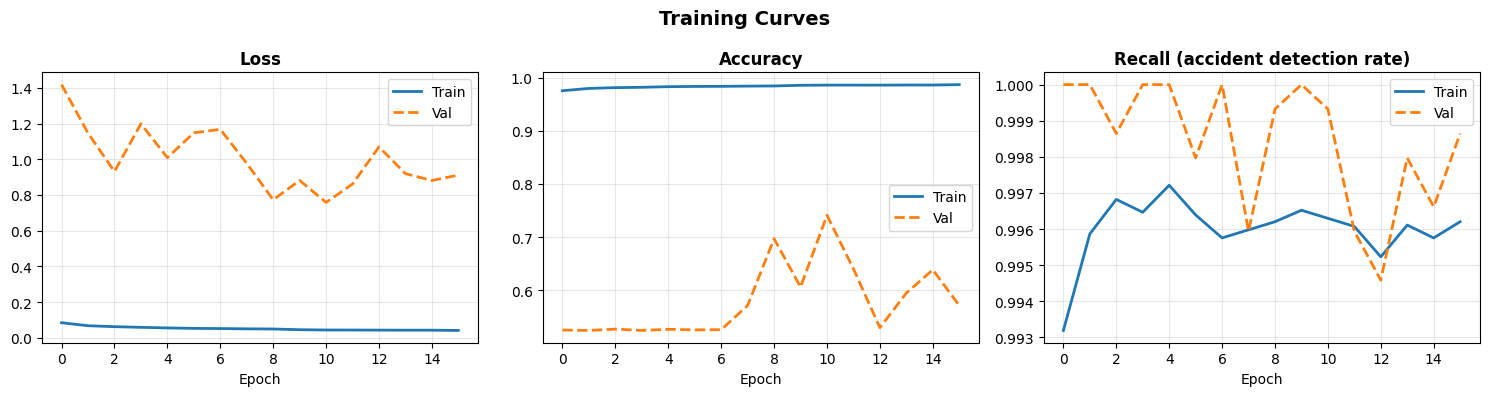


Final val accuracy : 0.5714
Final val recall   : 0.9986

✅ Accuracy looks realistic — not suspiciously perfect.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Training Curves", fontsize=14, fontweight='bold')

for ax, metric, title in zip(
    axes,
    ['loss', 'acc', 'recall'],
    ['Loss', 'Accuracy', 'Recall (accident detection rate)']
):
    ax.plot(history.history[metric],            label='Train', linewidth=2)
    ax.plot(history.history[f'val_{metric}'],   label='Val',   linewidth=2, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / "training_curves.png", dpi=120, bbox_inches='tight')
plt.show()

final_val_acc    = history.history['val_acc'][-1]
final_val_recall = history.history['val_recall'][-1]
print(f"\nFinal val accuracy : {final_val_acc:.4f}")
print(f"Final val recall   : {final_val_recall:.4f}")
if final_val_acc > 0.98:
    print("\n⚠️  Val accuracy > 98% — double-check for remaining leakage if recall is also perfect.")
else:
    print("\n✅ Accuracy looks realistic — not suspiciously perfect.")


TEST SET EVALUATION
              precision    recall  f1-score   support

      Normal     0.9789    0.9182    0.9476      1113
    Accident     0.2661    0.6000    0.3687        55

    accuracy                         0.9033      1168
   macro avg     0.6225    0.7591    0.6582      1168
weighted avg     0.9454    0.9033    0.9204      1168

Confusion Matrix:
  True Negatives  (TN): 1,022  — normal correctly ignored
  False Positives (FP): 91  — false alarms
  False Negatives (FN): 22  — ⚠️  missed accidents!
  True Positives  (TP): 33  — accidents correctly caught

False alarm rate (FPR): 0.0818
Miss rate        (FNR): 0.4000  ← critical for safety

ROC-AUC : 0.7172
PR-AUC  : 0.2515  ← primary metric (imbalanced classes)


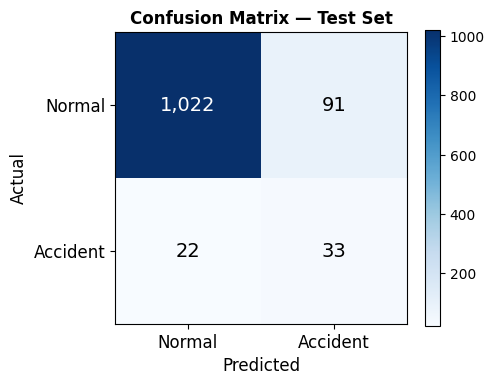

In [ ]:
y_prob = model.predict(X_test, verbose=0).squeeze()
y_pred = (y_prob >= 0.5).astype(int)

print("=" * 55)
print("TEST SET EVALUATION")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=["Normal", "Accident"], digits=4))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion Matrix:")
print(f"  True Negatives  (TN): {tn:,}  — normal correctly ignored")
print(f"  False Positives (FP): {fp:,}  — false alarms")
print(f"  False Negatives (FN): {fn:,}  — ⚠️  missed accidents!")
print(f"  True Positives  (TP): {tp:,}  — accidents correctly caught")

fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
print(f"\nFalse alarm rate (FPR): {fpr:.4f}")
print(f"Miss rate        (FNR): {fnr:.4f}  ← critical for safety")

roc    = roc_auc_score(y_test, y_prob)
prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(rec_c, prec_c)
print(f"\nROC-AUC : {roc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}  ← primary metric (imbalanced classes)")

# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Normal", "Accident"], fontsize=12)
ax.set_yticklabels(["Normal", "Accident"], fontsize=12)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title("Confusion Matrix — Test Set", fontweight='bold')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}", ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.savefig(MODELS_DIR / "confusion_matrix.png", dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
print(f"{'Threshold':>10} {'Recall':>8} {'Precision':>10} {'False Alarms':>14} {'Missed Accidents':>18}")
print("─" * 68)

for thresh in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    yp  = (y_prob >= thresh).astype(int)
    tp_ = ((yp==1) & (y_test==1)).sum()
    fp_ = ((yp==1) & (y_test==0)).sum()
    fn_ = ((yp==0) & (y_test==1)).sum()
    recall_    = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0
    precision_ = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 0
    marker = " ← recommended" if thresh == 0.3 else ""
    print(f"{thresh:>10.1f} {recall_:>8.3f} {precision_:>10.3f} {fp_:>14,} {fn_:>18,}{marker}")

print("\n💡 For a safety-critical system, consider threshold 0.3–0.4")
print("   to maximize recall (fewer missed accidents).")


 Threshold   Recall  Precision   False Alarms   Missed Accidents
────────────────────────────────────────────────────────────────────
       0.2    0.891      0.044          1,062                  6
       0.3    0.855      0.043          1,041                  8 ← recommended
       0.4    0.745      0.070            548                 14
       0.5    0.600      0.266             91                 22
       0.6    0.545      0.303             69                 25
       0.7    0.473      0.342             50                 29
       0.8    0.364      0.312             44                 35

💡 For a safety-critical system, consider threshold 0.3–0.4
   to maximize recall (fewer missed accidents).
